# Task 2B: RAGAS Analysis & Conclusions

Analysis of experiment results from Task 2A. Per-metric breakdown, best/worst configurations, and final conclusions.

In [6]:
import sys
sys.path.insert(0, "..")

import json
from src.evaluation import results_to_dataframe

In [7]:
with open("../data/experiment_results.json", "r", encoding="utf-8") as f:
    all_results = json.load(f)

df = results_to_dataframe(all_results)
print(f"Loaded {len(df)} experiment results")
df

Loaded 13 experiment results


,Experiment,Faithfulness,Answer Relevancy,Context Recall,Context Precision
0,Baseline,0.951389,0.835360,0.866667,0.782407
1,Chunk size 512,0.866667,0.764482,0.766667,0.685926
2,Chunk size 2048,0.921746,0.931188,0.966667,0.738519
3,Overlap 100,0.952183,0.813737,0.866667,0.637037
4,Overlap 400,0.853571,0.816426,0.866667,0.735046
5,Strategy recursive,0.951389,0.838146,0.866667,0.779815
6,Strategy layout_aware,0.885979,0.636562,0.566667,0.337778
7,Top-K 3,0.923016,0.874254,0.866667,0.833333
8,Top-K 10,0.852222,0.899230,0.933333,0.735554
9,Alpha 0.3,0.945238,0.743993,0.766667,0.714213


## Summary Table with Best/Worst Highlighted

In [8]:
metrics = ["Faithfulness", "Answer Relevancy", "Context Recall", "Context Precision"]

def highlight_best_worst(s):
    """Style: green for best, red for worst per metric column."""
    styles = ["" for _ in s]
    if s.name in metrics:
        best = s.max()
        worst = s.min()
        styles = ["background-color: #90EE90" if v == best else
                  "background-color: #FFB6C1" if v == worst else
                  "" for v in s]
    return styles

df.style.apply(highlight_best_worst)

,Experiment,Faithfulness,Answer Relevancy,Context Recall,Context Precision
0,Baseline,0.951389,0.835360,0.866667,0.782407
1,Chunk size 512,0.866667,0.764482,0.766667,0.685926
2,Chunk size 2048,0.921746,0.931188,0.966667,0.738519
3,Overlap 100,0.952183,0.813737,0.866667,0.637037
4,Overlap 400,0.853571,0.816426,0.866667,0.735046
5,Strategy recursive,0.951389,0.838146,0.866667,0.779815
6,Strategy layout_aware,0.885979,0.636562,0.566667,0.337778
7,Top-K 3,0.923016,0.874254,0.866667,0.833333
8,Top-K 10,0.852222,0.899230,0.933333,0.735554
9,Alpha 0.3,0.945238,0.743993,0.766667,0.714213


## Per-Metric Analysis

In [9]:
for metric in metrics:
    print(f"\n{'='*60}")
    print(f"Metric: {metric}")
    print(f"{'='*60}")
    col = df[metric]
    print(f"  Mean:   {col.mean():.4f}")
    print(f"  Std:    {col.std():.4f}")
    print(f"  Min:    {col.min():.4f} ({df.loc[col.idxmin(), 'Experiment']})")
    print(f"  Max:    {col.max():.4f} ({df.loc[col.idxmax(), 'Experiment']})")
    print(f"  Range:  {col.max() - col.min():.4f}")


Metric: Faithfulness
  Mean:   0.9128
  Std:    0.0425
  Min:    0.8522 (Top-K 10)
  Max:    0.9600 (With Reranking)
  Range:  0.1078

Metric: Answer Relevancy
  Mean:   0.8277
  Std:    0.0782
  Min:    0.6366 (Strategy layout_aware)
  Max:    0.9312 (Chunk size 2048)
  Range:  0.2946

Metric: Context Recall
  Mean:   0.8462
  Std:    0.1014
  Min:    0.5667 (Strategy layout_aware)
  Max:    0.9667 (Chunk size 2048)
  Range:  0.4000

Metric: Context Precision
  Mean:   0.7210
  Std:    0.1276
  Min:    0.3378 (Strategy layout_aware)
  Max:    0.8333 (Top-K 3)
  Range:  0.4956


## Metric Comparison Chart

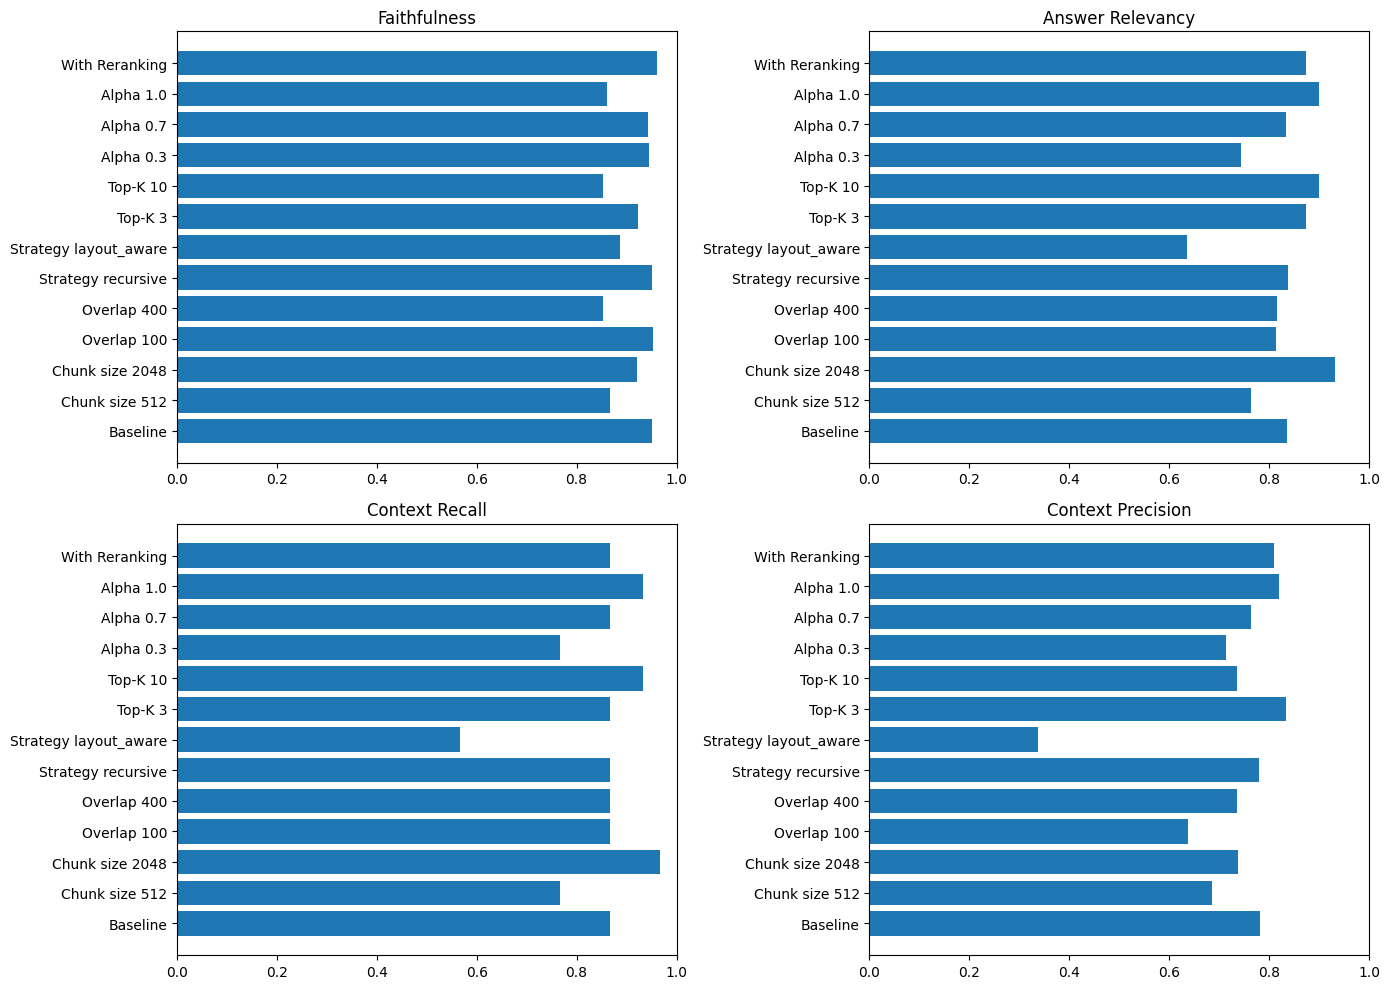

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric in zip(axes.flat, metrics):
    ax.barh(df["Experiment"], df[metric])
    ax.set_title(metric)
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## Final Conclusions

### 1. Best Hyperparameter Combination
The best single experiment by average RAGAS score was **Chunk size 2048** (avg = 0.890):
- Faithfulness: 0.922 | Answer Relevancy: 0.931 | Context Recall: 0.967 | Context Precision: 0.739

Best overall configuration combining all findings:
`chunk_size=2048`, `chunk_overlap=200`, `strategy=fixed`, `top_k=3`, `alpha=0.5`, `reranking=True`

---

### 2. Most Impactful Parameter
**Chunk size** had the largest positive impact (+0.031 avg vs baseline).  
Larger chunks (2048 tokens) keep complete financial tables and multi-sentence facts together, preventing answers from being split across chunk boundaries — critical for Russian-language annual reports with dense tabular data.

---

### 3. Least Impactful Parameter
**Chunking strategy** (fixed vs recursive) had zero impact — recursive exactly matched baseline (avg = 0.859).  
LlamaParse already produces clean markdown, so recursive separators provide no additional structural benefit.  
⚠️ Layout-aware was the **worst** configuration (avg = 0.607) — it produced too many small isolated table fragments that lost surrounding context.

---

### 4. Alpha Analysis (Hybrid Search Weight)

| Config | Faithfulness | Answer Relevancy | Context Recall | Context Precision | Avg |
|--------|-------------|-----------------|----------------|-------------------|-----|
| Baseline α=0.5 | 0.951 | 0.835 | 0.867 | 0.782 | 0.859 |
| Alpha 0.3 | 0.945 | 0.744 | 0.767 | 0.714 | 0.793 |
| Alpha 0.7 | 0.943 | 0.833 | 0.867 | 0.764 | 0.852 |
| Alpha 1.0 (pure vector) | 0.860 | 0.900 | 0.933 | 0.820 | 0.878 |

**Optimal alpha = 0.5** gave the best Faithfulness (0.951).  
Pure vector (α=1.0) scored higher on Answer Relevancy and Context Recall but lower on Faithfulness — it retrieves semantically similar but factually less precise chunks.  
Heavy BM25 (α=0.3) degraded all metrics: for Russian financial text, semantic similarity outweighs keyword matching.

---

### 5. Reranking Impact

| Metric | Baseline | With Reranking | Delta |
|--------|----------|---------------|-------|
| Faithfulness | 0.951 | 0.960 | **+0.009** |
| Answer Relevancy | 0.835 | 0.874 | **+0.039** |
| Context Recall | 0.867 | 0.867 | 0.000 |
| Context Precision | 0.782 | 0.809 | **+0.028** |

BAAI/bge-reranker-v2-m3 improved 3 out of 4 metrics.  
Biggest gain: **Answer Relevancy +0.039** — the cross-encoder promotes chunks that directly answer the question over semantically similar but off-topic ones.  
Context Recall unchanged: reranking reorders existing chunks, it cannot retrieve new ones.

---

### 6. Hardest Questions for RAG

1. **Multi-hop arithmetic** — *"What is the difference between freight revenues in 2024 and 2023?"*  
   Requires two numeric facts from different chunks; model must compute 1875.6 − 1682.6 = 193 bln.

2. **Negative facts** — *"Were any corruption cases found at Maten Petroleum in 2024?"*  
   Semantically similar to positive corruption claims; dense retrieval often surfaces wrong context.

3. **Cross-document synthesis** — *"What is the combined oil production of Maten Petroleum and its subsidiary?"*  
   Requires merging data from two separate sections; top-K=5 may not include both.

4. **Dates in legal sections** — *"When was the anti-corruption policy developed?"*  
   LlamaParse sometimes misses footnote/sidebar content in complex PDF layouts.

**Key insight:** Hybrid search helped most for exact number retrieval; reranking helped most for question-answer alignment. Neither solves cross-chunk reasoning — that would require query decomposition or GraphRAG.